In [1]:
from fom import fom
from onedprojection import onedprojection
import matplotlib.pyplot as plt
from scipy import sparse
import numpy as np
from common import set_figure

# poisson problem

In [2]:
n = 100
A = sparse.diags([-1, 2, -1], [-1, 0, 1], shape=(n,n), format='csr')
b = np.zeros((n,))

test SD vs FOM

In [3]:
its = 100

x0 = np.random.rand(n)
res = []
err = []
res2 = []
err2 = []

x = onedprojection(A, b, x0=x0, tol=1e-8, maxiter=its, residuals=res, method='SD', errs=err)

x2 = fom(A, b, x0=x0, maxiter=its, residuals=res2, errs=err2)

<>:1: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<>:2: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<>:3: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<>:4: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<>:6: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<>:1: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<>:2: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not w

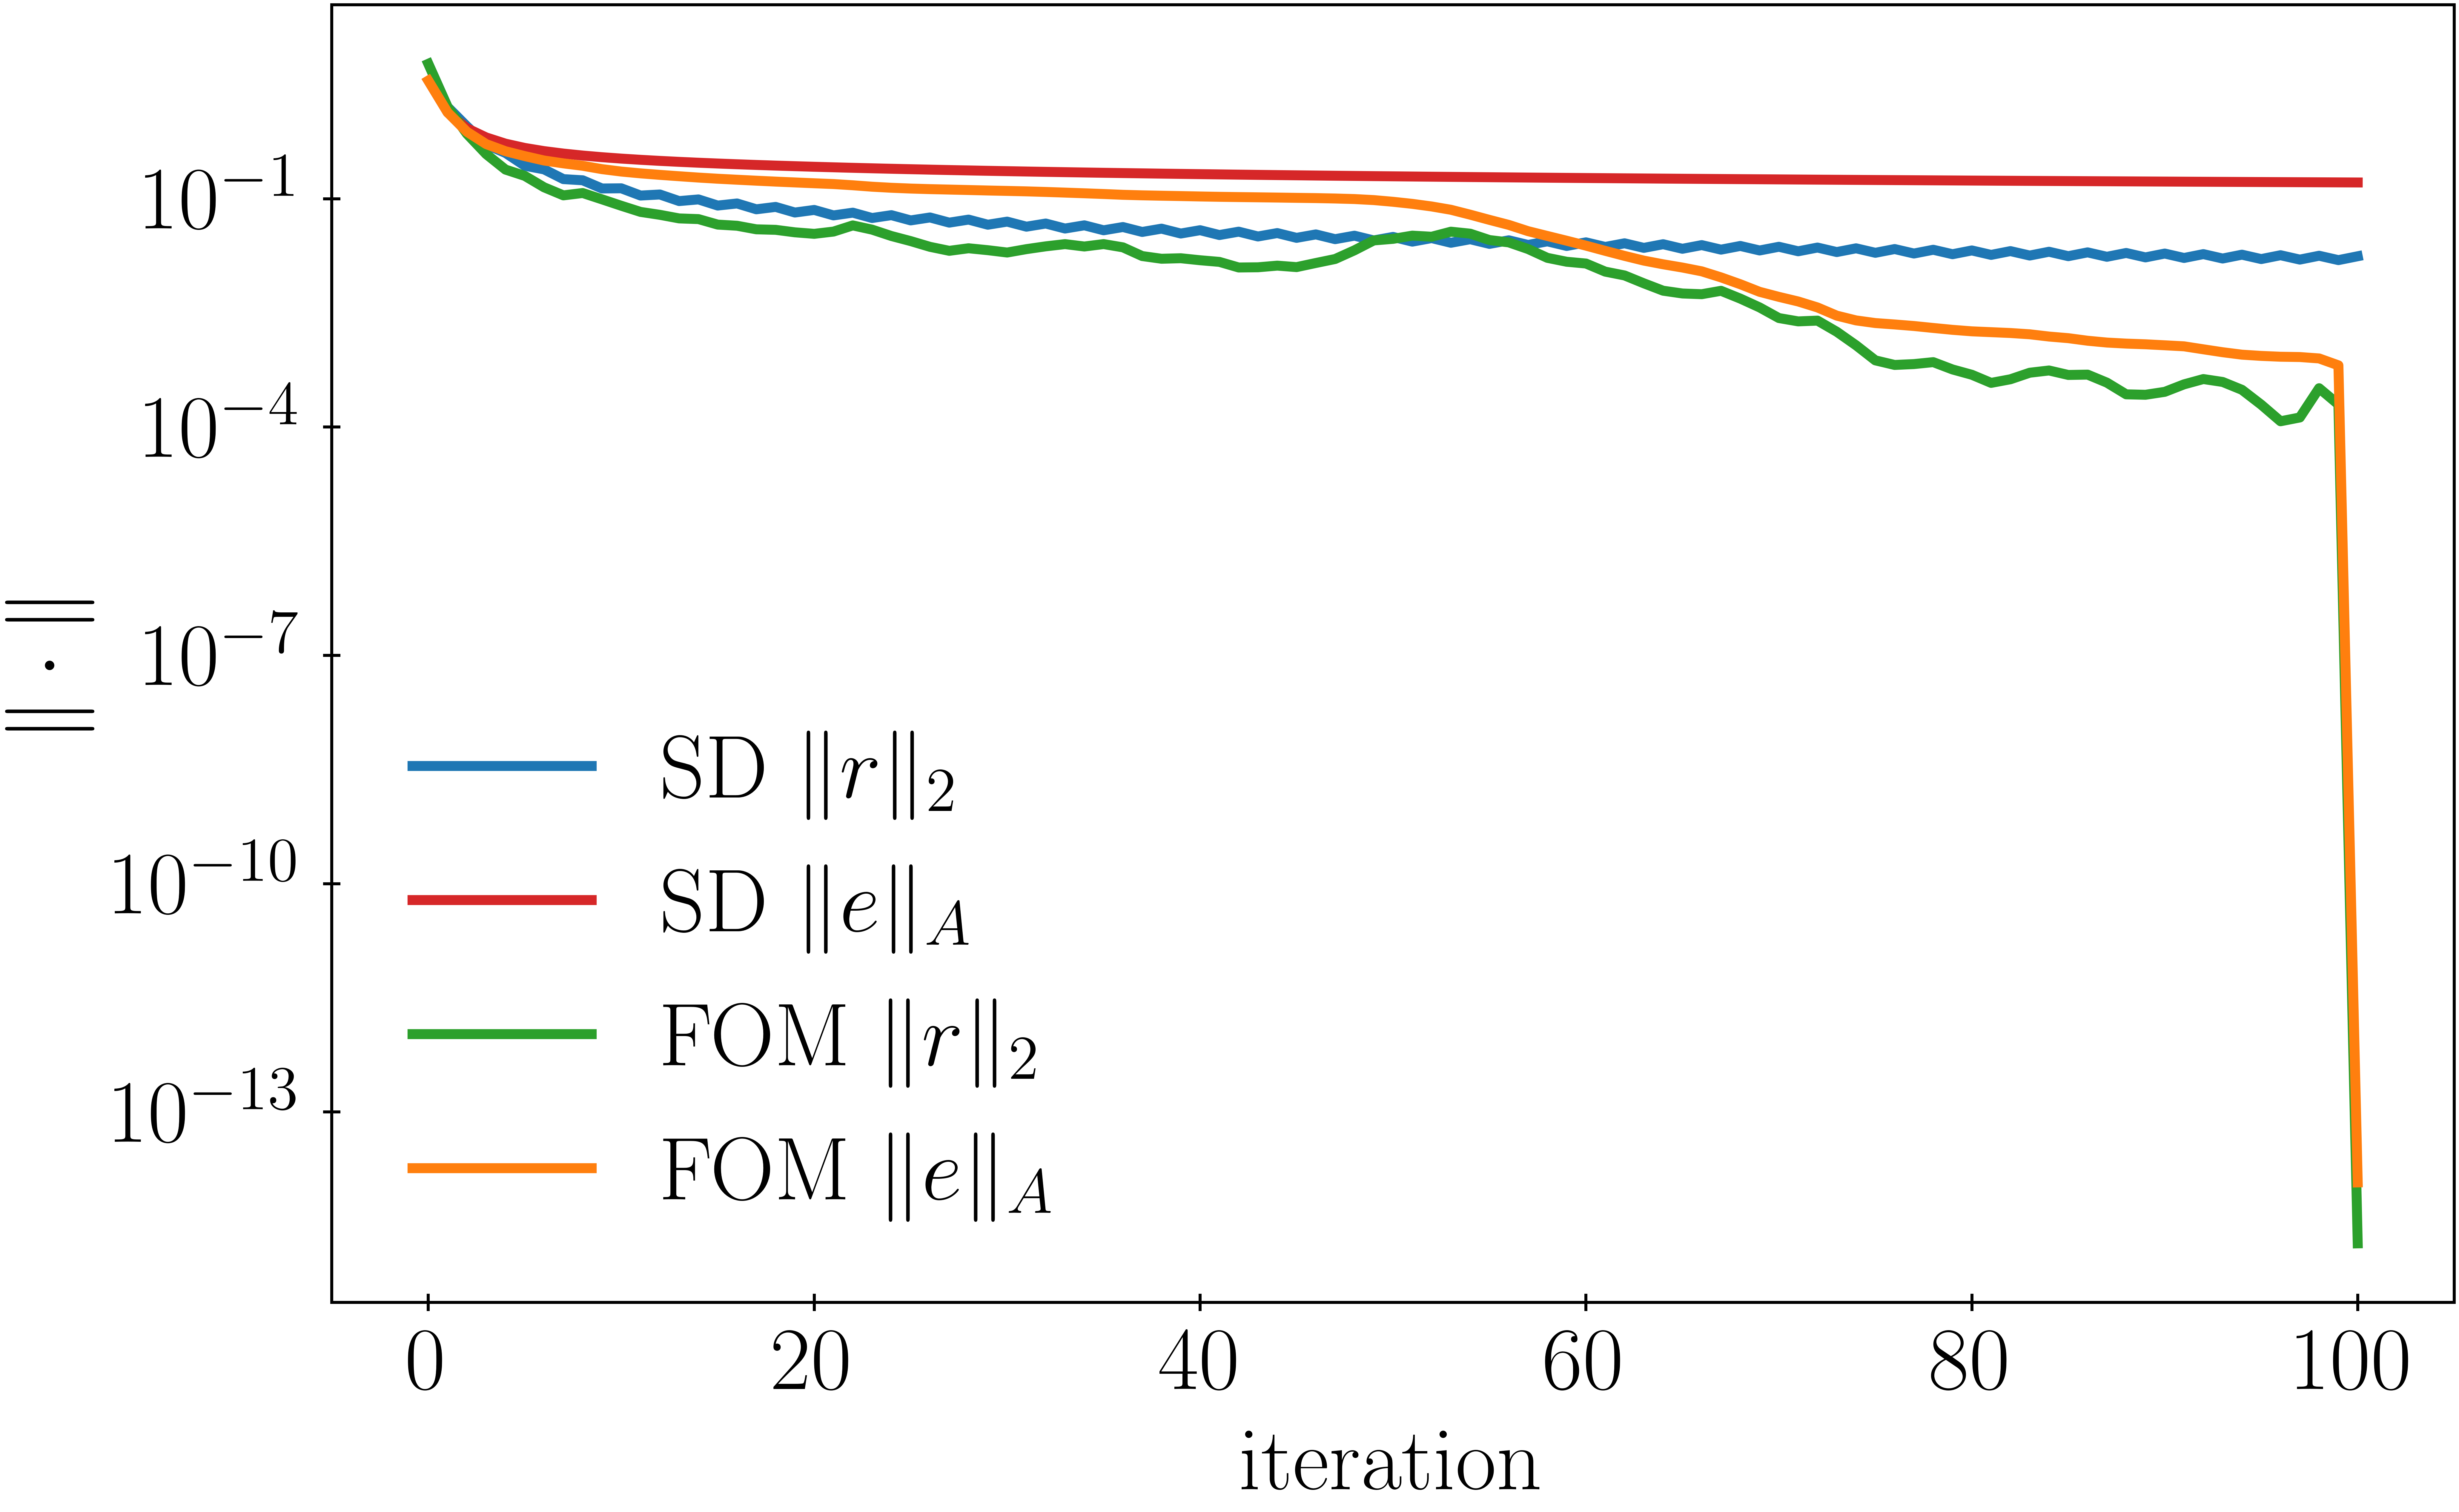

In [4]:
plt.semilogy(res, label='SD $\|r\|_2$')
plt.semilogy(err, label='SD $\|e\|_A$')
plt.semilogy(res2, label='FOM $\|r\|_2$')
plt.semilogy(err2, label='FOM $\|e\|_A$')
plt.xlabel("iteration")
plt.ylabel("$\|\cdot\|$")
plt.legend()

# a different model problem

In [5]:
n = 8
d = np.linspace(0.1,1.0,n)
d[0] = 0.0001
d[1] = 0.009
d[2] = 0.008
d[3] = 0.0007
A = sparse.spdiags(d,[0],n,n).tocsr()

np.set_printoptions(precision=4, suppress=True)
print(A.toarray())

[[0.0001 0.     0.     0.     0.     0.     0.     0.    ]
 [0.     0.009  0.     0.     0.     0.     0.     0.    ]
 [0.     0.     0.008  0.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.0007 0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.6143 0.     0.     0.    ]
 [0.     0.     0.     0.     0.     0.7429 0.     0.    ]
 [0.     0.     0.     0.     0.     0.     0.8714 0.    ]
 [0.     0.     0.     0.     0.     0.     0.     1.    ]]


In [6]:
its = 200

n = 200
d = np.linspace(0.1,1.0,n)
d[0] = 0.0001
d[1] = 0.009
A = sparse.spdiags(d,[0],n,n).tocsr()

b = np.zeros((n,))
x0 = np.random.rand(n)
res = []
err = []
res2 = []
err2 = []

x = onedprojection(A,b,x0=x0,tol=1e-8,maxiter=its,residuals=res,method='SD',errs=err)
x2 = fom(A,b,x0=x0,maxiter=its,residuals=res2,errs=err2)

In [7]:
plt.figure(figsize=(8,8))
plt.semilogy(res, label='SD $\|r\|_2$')
plt.semilogy(err, label='SD $\|e\|_A$')
plt.semilogy(res2, label='FOM $\|r\|_2$')
plt.semilogy(err2, label='FOM $\|e\|_A$')
plt.xlabel("iteration")
plt.ylabel("$\|\cdot\|$")
plt.legend()
#plt.savefig('09-13-img.png')

<>:2: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<>:3: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<>:4: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<>:5: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<>:7: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<>:2: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<>:3: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not w

## ratio of residuals

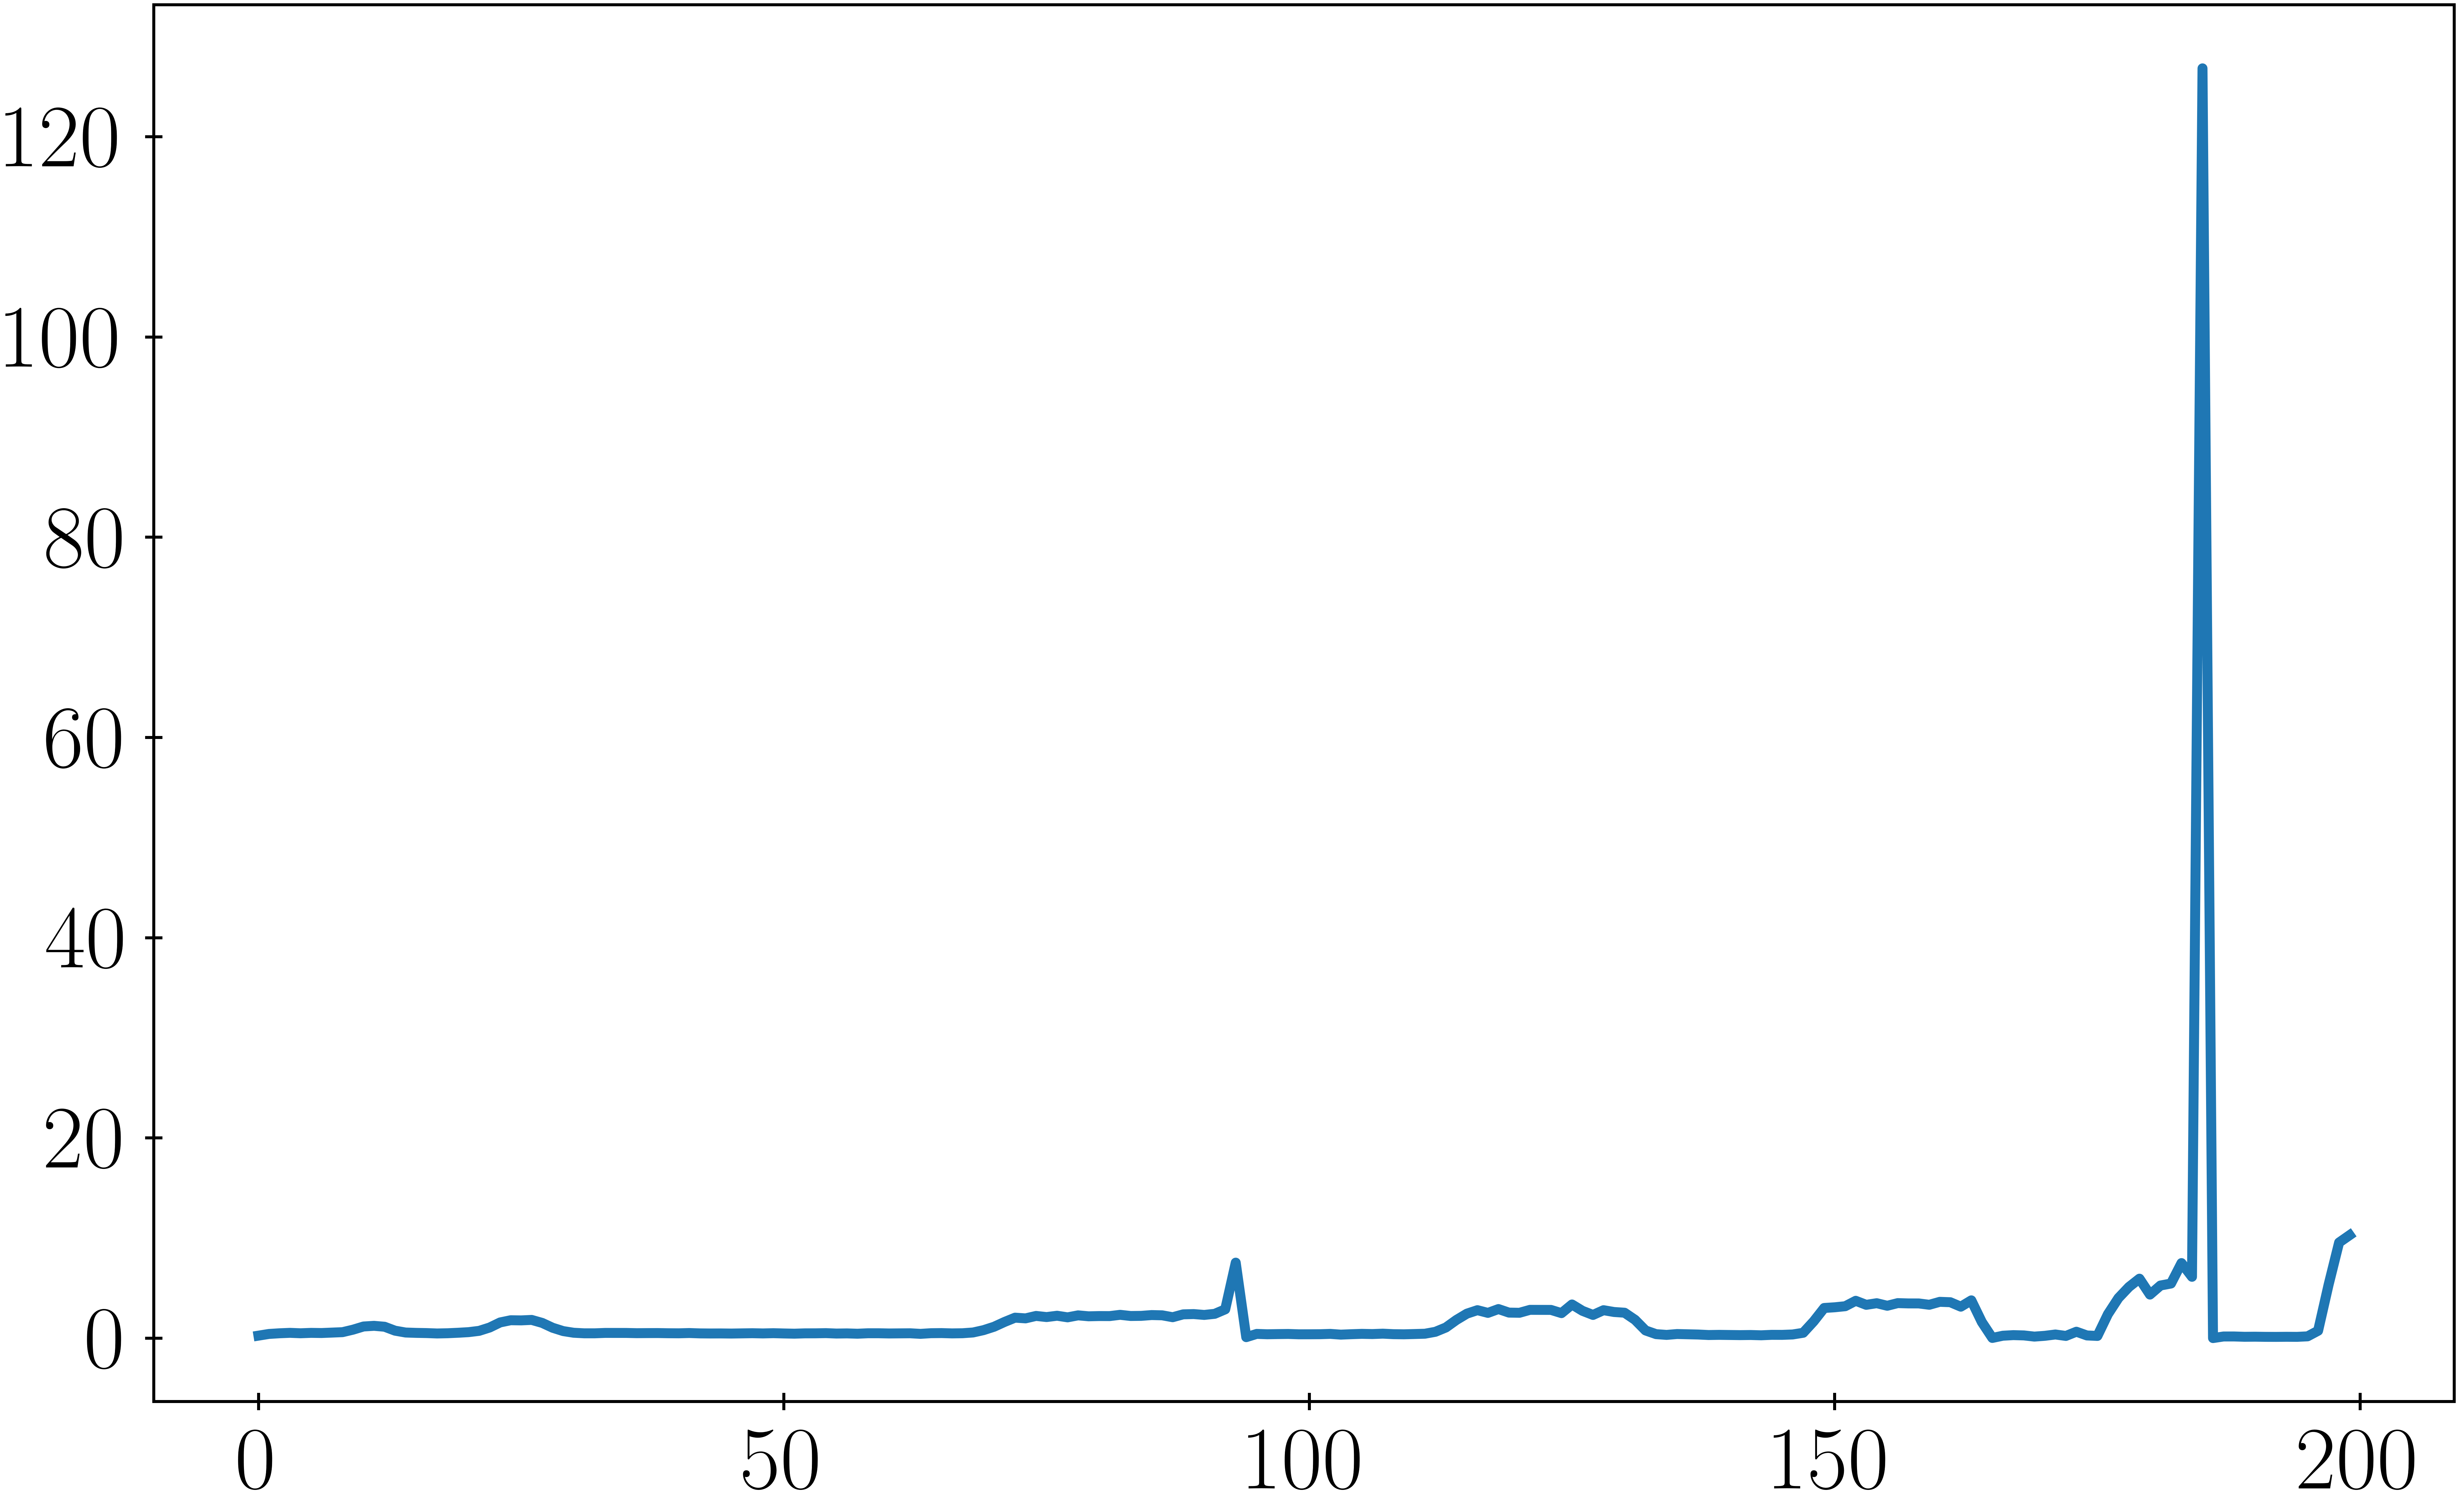

In [8]:
res2 = np.array(res2)
plt.plot(res2[1:] / res2[:-1])